<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Total_RU_DEm_EVO_DGM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# -*- coding: utf-8 -*-
"""
MADDPG CORE - Исправленная версия 1.1
Файл 1/3: Базовые компоненты и алгоритмы
ИСПРАВЛЕНО: импорты, совместимость, стабильность, общая функция награды, улучшен DGM-модуль
"""

import os
import math
import time
import json
import random
import warnings
import copy
from datetime import datetime
from collections import deque, defaultdict
from typing import Dict, List, Tuple, Optional, Union, Any

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Исправленный импорт tqdm для Google Colab
try:
    from tqdm.auto import tqdm
except ImportError:
    try:
        from tqdm import tqdm
    except ImportError:
        # Fallback для случаев когда tqdm недоступен
        def tqdm(iterable, *args, **kwargs):
            desc = kwargs.get('desc', '')
            total = len(iterable) if hasattr(iterable, '__len__') else None
            for i, item in enumerate(iterable):
                if desc and total:
                    if i % max(1, total // 20) == 0:
                        print(f"{desc}: {i+1}/{total}")
                yield item

warnings.filterwarnings('ignore')

# Настройки для воспроизводимости
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("🚀 MADDPG CORE V1.1 - ИСПРАВЛЕННАЯ ВЕРСИЯ")
print(f"📱 Устройство: {DEVICE}")
print(f"🎯 Seed: {SEED}")

# ===== КОНФИГУРАЦИЯ =====
CONFIG = {
    'training_epochs': 1000,
    'testing_epochs': 200,
    'region_addition_phase': 600,
    'total_regions': 86,
    'batch_size': 32,
    'episode_length': 15,
    'buffer_size': 50000,
    'log_interval': 10,
    'milestone_interval': 10,
}

# ===== ОБЩАЯ (СТАРТОВАЯ)  ФУНКЦИЯ НАГРАДЫ =====
REWARD_WEIGHTS = {
    'population': 2.0,
    'natural_increase_rate': 3.0,
    'birth_rate': 2.5,
    'death_rate': -2.0,
    'migration_balance': 2.2,
    'gdp_per_capita': 1.8,
    'average_wage': 1.5,
    'unemployment_rate': -1.8,
    'stability_bonus': 1.0
}

def calculate_honest_reward(region_data: dict, actions: np.ndarray = None) -> float:
    """
    Общая  функция награды у всех алгоритмов - учатсников эксперимента
    Основана только на демографических и экономических метриках
    """
    if not region_data:
        return 0.0

    reward = 0.0

    # Основные компоненты
    base_components = ['population', 'natural_increase_rate', 'birth_rate',
                      'death_rate', 'migration_balance', 'gdp_per_capita',
                      'average_wage', 'unemployment_rate']

    for component in base_components:
        if component in region_data:
            value = float(region_data[component])
            if not np.isnan(value) and not np.isinf(value):
                weight = REWARD_WEIGHTS.get(component, 0)
                reward += weight * np.clip(value, -3.0, 3.0)

    # Динамические компоненты (изменения)
    delta_weights = {
        'delta_population': 1.5,
        'delta_birth_rate': 2.0,
        'delta_gdp_per_capita': 1.8,
        'delta_migration_balance': 1.6,
        'delta_average_wage': 1.2
    }

    for delta_key, weight in delta_weights.items():
        if delta_key in region_data:
            delta_value = float(region_data[delta_key])
            if not np.isnan(delta_value) and not np.isinf(delta_value):
                reward += weight * np.clip(delta_value, -1.0, 1.0)

    # Бонус за стабильность
    if 'delta_population' in region_data:
        delta_pop = float(region_data.get('delta_population', 0))
        if not np.isnan(delta_pop):
            stability = 1.0 / (1.0 + abs(delta_pop))
            reward += REWARD_WEIGHTS['stability_bonus'] * stability

    # Небольшой штраф за действия (регуляризация)
    if actions is not None and len(actions) > 0:
        action_penalty = 0.01 * np.sum(np.square(actions))
        reward -= action_penalty

    # Базовый сдвиг для положительных значений
    reward += 1.0

    return float(np.clip(reward, -20.0, 20.0))

# ===== НЕЙРОННЫЕ СЕТИ =====
class Actor(nn.Module):
    """Улучшенная архитектура актора"""
    def __init__(self, state_dim: int, action_dim: int):
        super(Actor, self).__init__()

        self.fc1 = nn.Linear(state_dim, 400)
        self.bn1 = nn.BatchNorm1d(400)
        self.fc2 = nn.Linear(400, 300)
        self.bn2 = nn.BatchNorm1d(300)
        self.fc3 = nn.Linear(300, action_dim)

        self.dropout = nn.Dropout(0.1)

        # Инициализация весов
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.uniform_(self.fc3.weight, -3e-3, 3e-3)

    def forward(self, state):
        if state.dim() == 1:
            state = state.unsqueeze(0)

        x = self.fc1(state)
        if x.size(0) > 1:  # BatchNorm только если batch_size > 1
            x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        if x.size(0) > 1:
            x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = torch.tanh(self.fc3(x))
        return x

class Critic(nn.Module):
    """Улучшенная архитектура критика"""
    def __init__(self, state_dim: int, action_dim: int):
        super(Critic, self).__init__()

        self.state_fc = nn.Linear(state_dim, 400)
        self.state_bn = nn.BatchNorm1d(400)

        self.action_fc = nn.Linear(action_dim, 100)

        self.combined_fc1 = nn.Linear(500, 300)
        self.combined_bn = nn.BatchNorm1d(300)
        self.combined_fc2 = nn.Linear(300, 1)

        self.dropout = nn.Dropout(0.1)

        # Инициализация весов
        nn.init.xavier_uniform_(self.state_fc.weight)
        nn.init.xavier_uniform_(self.action_fc.weight)
        nn.init.xavier_uniform_(self.combined_fc1.weight)
        nn.init.uniform_(self.combined_fc2.weight, -3e-3, 3e-3)

    def forward(self, state, action):
        if state.dim() == 1:
            state = state.unsqueeze(0)
        if action.dim() == 1:
            action = action.unsqueeze(0)

        # Обработка состояния
        state_feat = self.state_fc(state)
        if state_feat.size(0) > 1:
            state_feat = self.state_bn(state_feat)
        state_feat = F.relu(state_feat)

        # Обработка действия
        action_feat = F.relu(self.action_fc(action))

        # Объединение
        combined = torch.cat([state_feat, action_feat], dim=1)
        x = self.combined_fc1(combined)
        if x.size(0) > 1:
            x = self.combined_bn(x)
        x = F.relu(x)
        x = self.dropout(x)

        q_value = self.combined_fc2(x)
        return q_value

# ===== MADDPG АГЕНТ =====
class MADDPGAgent:
    """Улучшенный MADDPG агент с детальным мониторингом"""
    def __init__(self, agent_id: str, state_dim: int, action_dim: int):
        self.agent_id = agent_id
        self.state_dim = state_dim
        self.action_dim = action_dim

        # Сети
        self.actor = Actor(state_dim, action_dim).to(DEVICE)
        self.actor_target = Actor(state_dim, action_dim).to(DEVICE)
        self.critic = Critic(state_dim, action_dim).to(DEVICE)
        self.critic_target = Critic(state_dim, action_dim).to(DEVICE)

        # Инициализация целевых сетей
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.critic_target.load_state_dict(self.critic.state_dict())

        # Оптимизаторы
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=1e-4)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-3)

        # Гиперпараметры
        self.gamma = 0.99
        self.tau = 0.001

        # Метрики для анализа
        self.actor_losses = []
        self.critic_losses = []
        self.q_values = []
        self.update_count = 0

    def act(self, state, noise_std=0.2, training=True):
        """Генерация действия с шумом для исследования"""
        self.actor.eval()

        try:
            with torch.no_grad():
                if isinstance(state, np.ndarray):
                    state_tensor = torch.FloatTensor(state).to(DEVICE)
                else:
                    state_tensor = state.to(DEVICE)

                action = self.actor(state_tensor)
                action = action.cpu().data.numpy()

                if action.ndim > 1:
                    action = action[0]
        except Exception as e:
            print(f"Ошибка в act: {e}")
            action = np.random.uniform(-1, 1, size=self.action_dim)

        if training and noise_std > 0:
            noise = np.random.normal(0, noise_std, size=action.shape)
            action = action + noise

        self.actor.train()
        return np.clip(action, -1.0, 1.0)

    def update(self, batch_states, batch_actions, batch_rewards,
               batch_next_states, batch_dones):
        """Обновление параметров агента"""
        if len(batch_states) < 4:
            return

        try:
            # Конвертация в тензоры
            states = torch.FloatTensor(np.array(batch_states)).to(DEVICE)
            actions = torch.FloatTensor(np.array(batch_actions)).to(DEVICE)
            rewards = torch.FloatTensor(batch_rewards).to(DEVICE).unsqueeze(1)
            next_states = torch.FloatTensor(np.array(batch_next_states)).to(DEVICE)
            dones = torch.FloatTensor(batch_dones).to(DEVICE).unsqueeze(1)

            # Проверка размерностей
            if states.dim() == 1:
                states = states.unsqueeze(0)
            if next_states.dim() == 1:
                next_states = next_states.unsqueeze(0)
            if actions.dim() == 1:
                actions = actions.unsqueeze(0)

            # Обновление критика
            with torch.no_grad():
                next_actions = self.actor_target(next_states)
                target_q = self.critic_target(next_states, next_actions)
                target_q = rewards + (self.gamma * target_q * (1 - dones))

            current_q = self.critic(states, actions)

            # Сохранение метрик
            self.q_values.append(current_q.mean().item())

            critic_loss = F.mse_loss(current_q, target_q)
            self.critic_losses.append(critic_loss.item())

            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
            self.critic_optimizer.step()

            # Обновление актора (каждый второй шаг)
            if self.update_count % 2 == 0:
                predicted_actions = self.actor(states)
                actor_loss = -self.critic(states, predicted_actions).mean()
                self.actor_losses.append(actor_loss.item())

                self.actor_optimizer.zero_grad()
                actor_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
                self.actor_optimizer.step()

                # Мягкое обновление целевых сетей
                self._soft_update(self.actor_target, self.actor)
                self._soft_update(self.critic_target, self.critic)

            self.update_count += 1

        except Exception as e:
            print(f"Ошибка в update агента {self.agent_id}: {e}")

    def _soft_update(self, target_net, source_net):
        """Мягкое обновление целевых сетей"""
        for target_param, source_param in zip(target_net.parameters(),
                                            source_net.parameters()):
            target_param.data.copy_(
                self.tau * source_param.data + (1.0 - self.tau) * target_param.data
            )

    def get_metrics(self):
        """Получение метрик для анализа"""
        return {
            'actor_loss': np.mean(self.actor_losses[-10:]) if self.actor_losses else 0.0,
            'critic_loss': np.mean(self.critic_losses[-10:]) if self.critic_losses else 0.0,
            'avg_q_value': np.mean(self.q_values[-10:]) if self.q_values else 0.0,
            'update_count': self.update_count
        }

# ===== БУФЕР ОПЫТА =====
class ReplayBuffer:
    """Улучшенный буфер опыта с проверками валидности данных"""
    def __init__(self, capacity=50000):
        self.capacity = capacity
        self.buffer = []
        self.position = 0

    def push(self, state, action, reward, next_state, done):
        """Добавление опыта с проверками на NaN"""
        try:
            # Проверка на валидность данных
            if (np.isnan(state).any() or np.isnan(action).any() or
                np.isnan(reward) or np.isnan(next_state).any()):
                return False

            experience = (
                np.array(state, dtype=np.float32),
                np.array(action, dtype=np.float32),
                float(reward),
                np.array(next_state, dtype=np.float32),
                bool(done)
            )

            if len(self.buffer) < self.capacity:
                self.buffer.append(experience)
            else:
                self.buffer[self.position] = experience

            self.position = (self.position + 1) % self.capacity
            return True

        except Exception as e:
            print(f"Ошибка в ReplayBuffer.push: {e}")
            return False

    def sample(self, batch_size):
        """Сэмплирование батча"""
        if len(self.buffer) < batch_size:
            return None

        try:
            indices = np.random.choice(len(self.buffer), batch_size, replace=False)
            batch = [self.buffer[idx] for idx in indices]

            states, actions, rewards, next_states, dones = zip(*batch)

            return states, actions, rewards, next_states, dones
        except Exception as e:
            print(f"Ошибка в ReplayBuffer.sample: {e}")
            return None

    def __len__(self):
        return len(self.buffer)

# ===== УЛУЧШЕННАЯ ЭВОЛЮЦИЯ =====
class EnhancedEvolution:
    """Улучшенный эволюционный алгоритм с адаптивными параметрами"""
    def __init__(self):
        self.generation = 0
        self.mutation_rate = 0.1
        self.mutation_strength = 0.02
        self.elite_fraction = 0.3

        # Адаптивные параметры
        self.performance_history = []
        self.stagnation_counter = 0
        self.max_stagnation = 5

    def evolve_population(self, agents: Dict[str, MADDPGAgent],
                         fitness_scores: Dict[str, float]) -> Dict[str, float]:
        """Эволюция популяции с улучшенной селекцией и разнообразием"""
        if len(agents) < 2:
            return {}

        try:
            # Очистка fitness от NaN
            clean_fitness = {}
            for agent_id, fitness in fitness_scores.items():
                if np.isnan(fitness) or np.isinf(fitness):
                    clean_fitness[agent_id] = -999.0
                else:
                    clean_fitness[agent_id] = float(fitness)

            # Анализ стагнации
            current_best = max(clean_fitness.values()) if clean_fitness else 0
            self.performance_history.append(current_best)

            if len(self.performance_history) > 5:
                recent_improvement = (self.performance_history[-1] -
                                    self.performance_history[-5])
                if abs(recent_improvement) < 0.01:
                    self.stagnation_counter += 1
                else:
                    self.stagnation_counter = 0

            # Адаптация параметров при стагнации
            if self.stagnation_counter > self.max_stagnation:
                self.mutation_rate = min(0.3, self.mutation_rate * 1.2)
                self.mutation_strength = min(0.1, self.mutation_strength * 1.1)
                self.stagnation_counter = 0
            else:
                self.mutation_rate = max(0.05, self.mutation_rate * 0.99)
                self.mutation_strength = max(0.01, self.mutation_strength * 0.99)

            # Сортировка по фитнесу
            agent_items = list(agents.items())
            sorted_agents = sorted(agent_items,
                                 key=lambda x: clean_fitness.get(x[0], -999),
                                 reverse=True)

            elite_count = max(1, int(len(sorted_agents) * self.elite_fraction))

            improvements = {}
            mutations_applied = 0

            # Мутация не-элитных агентов
            for i in range(elite_count, len(sorted_agents)):
                agent_id, agent = sorted_agents[i]

                improvement = self._adaptive_mutate_agent(agent)
                improvements[agent_id] = improvement
                mutations_applied += 1

            self.generation += 1

            # Логирование
            if mutations_applied > 0:
                valid_improvements = [v for v in improvements.values()
                                    if not np.isnan(v) and not np.isinf(v)]
                if valid_improvements:
                    avg_improvement = np.mean(valid_improvements)
                    print(f"🧬 Эволюция G{self.generation}: {mutations_applied} мутаций, "
                          f"улучшение: {avg_improvement:.4f}")

            return improvements

        except Exception as e:
            print(f"Ошибка в эволюции: {e}")
            return {}

    def _adaptive_mutate_agent(self, agent: MADDPGAgent) -> float:
        """Адаптивная мутация агента"""
        total_change = 0.0
        param_count = 0

        try:
            with torch.no_grad():
                for param in agent.actor.parameters():
                    if random.random() < self.mutation_rate:
                        noise = torch.randn_like(param) * self.mutation_strength
                        old_param = param.clone()
                        param.add_(noise)

                        change = torch.sum(torch.abs(param - old_param)).item()
                        total_change += change
                        param_count += param.numel()

            return total_change / max(param_count, 1) if param_count > 0 else 0.0
        except Exception as e:
            print(f"Ошибка в мутации: {e}")
            return 0.0

# ===== УПРОЩЕННАЯ (БАЗА) DARWIN-GÖDEL MACHINE =====
class AdvancedDGM:
    """Упрощенная реализация Darwin-Gödel Machine"""
    def __init__(self):
        self.expertise_level = 0.0
        self.last_adaptation_epoch = -1
        self.cooldown = 10

        # Архитектурные модификации
        self.architecture_changes = 0
        self.last_architecture_change = -30

        # Система кризисного восстановления
        self.crisis_specialists = {}
        self.crisis_threshold = -5.0
        self.crisis_detected = False

        # Автоматическое проектирование наград
        self.reward_components = REWARD_WEIGHTS.copy()
        self.reward_adaptation_history = []

        # Мета-обучение
        self.meta_learning_memory = {}
        self.adaptation_success_rate = 0.0

    def adapt_system(self, epoch: int, active_regions: List[str],
                    recent_performance: Dict = None,
                    agents: Dict[str, MADDPGAgent] = None) -> Dict[str, Any]:
        """Комплексная адаптация системы, вдохновленная идеей Darwin-Gödel Machine"""

        if epoch - self.last_adaptation_epoch < self.cooldown:
            return self._get_default_adaptations()

        adaptations = self._get_default_adaptations()

        try:
            # 1. Обнаружение кризиса
            crisis_detected = self._detect_crisis(recent_performance)

            if crisis_detected and not self.crisis_detected:
                print(f"🚨 DGM: Кризис обнаружен на эпохе {epoch}")
                self.crisis_detected = True
                adaptations.update(self._crisis_response(agents))
            elif not crisis_detected and self.crisis_detected:
                print(f"✅ DGM: Кризис преодолен на эпохе {epoch}")
                self.crisis_detected = False
                adaptations.update(self._post_crisis_adaptation(agents))

            # 2. Самооптимизация архитектуры
            if epoch - self.last_architecture_change > 29:
                arch_changes = self._self_modify_architecture(agents)
                if arch_changes > 0:
                    adaptations['architecture_modified'] = True
                    self.architecture_changes += arch_changes
                    self.last_architecture_change = epoch
                    print(f"🔧 DGM: Архитектурные изменения: {arch_changes}")

            # 3. Автоматическое проектирование наград
            reward_changes = self._redesign_reward_function(recent_performance)
            if reward_changes:
                adaptations['reward_function_modified'] = True
                print(f"🎯 DGM: Функция награды адаптирована")

            # 4. Адаптация к среде
            env_adaptations = self._environmental_adaptation(epoch, recent_performance)
            adaptations.update(env_adaptations)

            self.expertise_level = min(self.expertise_level + 0.01, 1.0)
            adaptations['confidence'] = 0.5 + self.expertise_level * 0.4

            self.last_adaptation_epoch = epoch

        except Exception as e:
            print(f"⚠️ DGM: Ошибка адаптации: {e}")
            return self._get_default_adaptations()

        return adaptations

    def _detect_crisis(self, recent_performance: Dict) -> bool:
        """Обнаружение кризисных ситуаций"""
        if not recent_performance:
            return False

        try:
            perf_values = []
            for v in recent_performance.values():
                if isinstance(v, (int, float)) and not np.isnan(v) and not np.isinf(v):
                    perf_values.append(v)

            if perf_values:
                avg_perf = np.mean(perf_values)
                return avg_perf < self.crisis_threshold

            return False
        except:
            return False

    def _crisis_response(self, agents: Dict[str, MADDPGAgent]) -> Dict[str, Any]:
        """Экстренный ответ на кризис"""
        adaptations = {}
        adaptations['learning_rate_multiplier'] = 1.5
        adaptations['exploration_bonus'] = 0.1
        adaptations['mutation_strength_multiplier'] = 2.0

        if agents:
            self._store_crisis_specialists(agents)

        return adaptations

    def _post_crisis_adaptation(self, agents: Dict[str, MADDPGAgent]) -> Dict[str, Any]:
        """Адаптация после преодоления кризиса"""
        adaptations = {}
        adaptations['learning_rate_multiplier'] = 0.8
        adaptations['exploration_bonus'] = -0.05

        if self.crisis_specialists and agents:
            self._transfer_crisis_knowledge(agents)

        return adaptations

    def _self_modify_architecture(self, agents: Dict[str, MADDPGAgent]) -> int:
        """Самомодификация архитектуры агентов"""
        if not agents:
            return 0

        modifications = 0

        try:
            # Примерная модификация: изменение dropout rate
            for agent in list(agents.values())[:2]:
                for module in agent.actor.modules():
                    if isinstance(module, nn.Dropout):
                        old_p = module.p
                        new_p = max(0.05, min(0.3, old_p + random.uniform(-0.05, 0.05)))
                        module.p = new_p
                        modifications += 1
        except:
            pass

        return modifications

    def _redesign_reward_function(self, recent_performance: Dict) -> bool:
        """Автоматическое проектирование функции награды"""
        if not recent_performance or len(self.reward_adaptation_history) < 5:
            self.reward_adaptation_history.append(recent_performance)
            return False

        try:
            recent_trend = np.mean([p.get('mean_reward', 0) for p in self.reward_adaptation_history[-3:]])
            earlier_trend = np.mean([p.get('mean_reward', 0) for p in self.reward_adaptation_history[-6:-3]])

            if recent_trend < earlier_trend * 0.95:
                # Адаптация весов награды
                for key in self.reward_components:
                    if 'rate' in key or 'balance' in key:
                        old_weight = REWARD_WEIGHTS[key]
                        new_weight = old_weight * (1 + random.uniform(-0.1, 0.1))
                        REWARD_WEIGHTS[key] = np.clip(new_weight, old_weight * 0.5, old_weight * 1.5)

                self.reward_adaptation_history.append(recent_performance)
                return True

            self.reward_adaptation_history.append(recent_performance)
            return False

        except:
            return False

    def _environmental_adaptation(self, epoch: int, recent_performance: Dict) -> Dict[str, Any]:
        """Адаптация к изменениям среды"""
        adaptations = {}

        if recent_performance:
            try:
                perf_values = [v for v in recent_performance.values()
                              if isinstance(v, (int, float)) and not np.isnan(v)]

                if perf_values:
                    avg_perf = np.mean(perf_values)

                    if avg_perf > 2.0:
                        adaptations['learning_rate_multiplier'] = 0.95
                        adaptations['exploration_bonus'] = -0.01
                    elif avg_perf < -1.0:
                        adaptations['learning_rate_multiplier'] = 1.05
                        adaptations['exploration_bonus'] = 0.02
            except:
                pass

        return adaptations

    def _store_crisis_specialists(self, agents: Dict[str, MADDPGAgent]):
        """Сохранение агентов-специалистов по кризисам"""
        try:
            if len(agents) > 0:
                best_agents = sorted(agents.items(),
                                   key=lambda x: np.mean(x[1].q_values[-10:]) if x[1].q_values else -999,
                                   reverse=True)[:3]

                crisis_type = f"crisis_{len(self.crisis_specialists)}"
                self.crisis_specialists[crisis_type] = {
                    'agents_params': [agent.actor.state_dict() for _, agent in best_agents],
                    'timestamp': time.time()
                }
        except:
            pass

    def _transfer_crisis_knowledge(self, agents: Dict[str, MADDPGAgent]):
        """Передача знаний от кризисных агентов"""
        try:
            if not self.crisis_specialists or not agents:
                return

            latest_crisis = max(self.crisis_specialists.items(), key=lambda x: x[1]['timestamp'])
            crisis_params = latest_crisis[1]['agents_params']

            if crisis_params and len(agents) > 0:
                agents_list = list(agents.values())
                for i, crisis_param in enumerate(crisis_params[:len(agents_list)]):
                    agent = agents_list[i]
                    with torch.no_grad():
                        for (name, agent_param), (_, crisis_param_tensor) in zip(
                            agent.actor.named_parameters(), crisis_param.items()):
                            if agent_param.shape == crisis_param_tensor.shape:
                                agent_param.data = 0.9 * agent_param.data + 0.1 * crisis_param_tensor
        except:
            pass

    def _get_default_adaptations(self):
        """Адаптации по умолчанию"""
        return {
            'learning_rate_multiplier': 1.0,
            'exploration_bonus': 0.0,
            'confidence': 0.5,
            'architecture_modified': False,
            'reward_function_modified': False
        }

print("✅ MADDPG CORE V1.1 - Все базовые компоненты загружены")
print("🔧 ИСПРАВЛЕНО: импорты, tqdm fallback, обработка ошибок")
print("📦 Доступны: Actor, Critic, MADDPGAgent, ReplayBuffer, EnhancedEvolution, AdvancedDGM")
print("🎯 функция награды: calculate_honest_reward")
print("⚙️ Конфигурация: CONFIG")

🚀 MADDPG CORE V1.1 - ИСПРАВЛЕННАЯ ВЕРСИЯ
📱 Устройство: cpu
🎯 Seed: 42
✅ MADDPG CORE V1.1 - Все базовые компоненты загружены
🔧 ИСПРАВЛЕНО: импорты, tqdm fallback, обработка ошибок
📦 Доступны: Actor, Critic, MADDPGAgent, ReplayBuffer, EnhancedEvolution, AdvancedDGM
🎯 функция награды: calculate_honest_reward
⚙️ Конфигурация: CONFIG


In [9]:
# -*- coding: utf-8 -*-
"""
MADDPG TRAINER - Исправленная версия 1.1
Файл 2/3: Среда, тренер, исправленный импорт
ИСПРАВЛЕНО: импорт tqdm, обработка ошибок, стабильность
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Union, Any

# Исправленный импорт tqdm
try:
    from tqdm.auto import tqdm
except ImportError:
    try:
        from tqdm import tqdm
    except ImportError:
        def tqdm(iterable, *args, **kwargs):
            desc = kwargs.get('desc', '')
            total = len(iterable) if hasattr(iterable, '__len__') else None
            for i, item in enumerate(iterable):
                if desc and total:
                    if i % max(1, total // 20) == 0:
                        print(f"{desc}: {i+1}/{total}")
                yield item

# Импорт переменных напрямую (для избежания проблем с импортом модуля)
import sys
import os

# Проверяем есть ли нужные классы в globals()
if 'MADDPGAgent' not in globals():
    print("⚠️ Классы не найдены в globals(), необходимо запустить первый файл")

print("🚀 MADDPG TRAINER V1.1 - ИСПРАВЛЕННАЯ ВЕРСИЯ")
print("📊 импорт tqdm и обработка ошибок")

# ===== КОПИРУЕМ КОНСТАНТЫ (на случай проблем с импортом) =====
if 'CONFIG' not in globals():
    CONFIG = {
        'training_epochs': 1000,
        'testing_epochs': 200,
        'region_addition_phase': 600,
        'total_regions': 86,
        'batch_size': 32,
        'episode_length': 15,
        'buffer_size': 50000,
        'log_interval': 10,
        'milestone_interval': 10,
    }

if 'DEVICE' not in globals():
    import torch
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if 'calculate_honest_reward' not in globals():
    REWARD_WEIGHTS = {
        'population': 2.0,
        'natural_increase_rate': 3.0,
        'birth_rate': 2.5,
        'death_rate': -2.0,
        'migration_balance': 2.2,
        'gdp_per_capita': 1.8,
        'average_wage': 1.5,
        'unemployment_rate': -1.8,
        'stability_bonus': 1.0
    }

    def calculate_honest_reward(region_data: dict, actions: np.ndarray = None) -> float:
        """Честная функция награды"""
        if not region_data:
            return 0.0

        reward = 0.0

        base_components = ['population', 'natural_increase_rate', 'birth_rate',
                          'death_rate', 'migration_balance', 'gdp_per_capita',
                          'average_wage', 'unemployment_rate']

        for component in base_components:
            if component in region_data:
                value = float(region_data[component])
                if not np.isnan(value) and not np.isinf(value):
                    weight = REWARD_WEIGHTS.get(component, 0)
                    reward += weight * np.clip(value, -3.0, 3.0)

        delta_weights = {
            'delta_population': 1.5,
            'delta_birth_rate': 2.0,
            'delta_gdp_per_capita': 1.8,
            'delta_migration_balance': 1.6,
            'delta_average_wage': 1.2
        }

        for delta_key, weight in delta_weights.items():
            if delta_key in region_data:
                delta_value = float(region_data[delta_key])
                if not np.isnan(delta_value) and not np.isinf(delta_value):
                    reward += weight * np.clip(delta_value, -1.0, 1.0)

        if 'delta_population' in region_data:
            delta_pop = float(region_data.get('delta_population', 0))
            if not np.isnan(delta_pop):
                stability = 1.0 / (1.0 + abs(delta_pop))
                reward += REWARD_WEIGHTS['stability_bonus'] * stability

        if actions is not None and len(actions) > 0:
            action_penalty = 0.01 * np.sum(np.square(actions))
            reward -= action_penalty

        reward += 1.0
        return float(np.clip(reward, -20.0, 20.0))

# ===== МОНИТОРИНГ  =====
class SmartMonitor:
    """Умный монитор"""
    def __init__(self):
        self.data = defaultdict(lambda: defaultdict(list))
        self.agent_creation_logged = False
        self.last_milestone = 0

    def start(self):
        timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
        print(f"⏰ Эксперимент начат: {timestamp}")

    def log_agent_creation(self, agent_count: int):
        """Логирование создания агентов"""
        milestones = [5, 10, 20, 30, 40, 50, 60, 70, 80, 86]

        for milestone in milestones:
            if agent_count >= milestone and self.last_milestone < milestone:
                print(f"✅ Создано {agent_count} агентов для регионов")
                self.last_milestone = milestone
                break

    def log(self, algorithm: str, epoch: int, reward: float, regions_count: int, info: dict = None):
        """Логирование прогресса обучения"""
        self.data[algorithm]['epochs'].append(epoch)
        self.data[algorithm]['rewards'].append(reward if not np.isnan(reward) else 0.0)
        self.data[algorithm]['regions'].append(regions_count)

        if info:
            for key, value in info.items():
                self.data[algorithm][key].append(value)

    def summary(self):
        """Итоговый отчет"""
        print("\\n" + "🏆" * 50)
        print("ИТОГИ ОБУЧЕНИЯ")
        print("🏆" * 50)

        for algo, metrics in self.data.items():
            if metrics['rewards']:
                clean_rewards = [r for r in metrics['rewards'] if not np.isnan(r)]
                if clean_rewards:
                    final = np.mean(clean_rewards[-20:]) if len(clean_rewards) >= 20 else np.mean(clean_rewards)
                    print(f"\\n{algo}: Финальная={final:.3f}, "
                          f"Максимум={max(clean_rewards):.3f}, "
                          f"Средняя={np.mean(clean_rewards):.3f}, "
                          f"Эпох={len(clean_rewards)}")

# ===== УЛУЧШЕННАЯ СРЕДА =====
class DemographyEnv:
    """демографическая среда"""

    def __init__(self, df: pd.DataFrame, obs_cols: List[str]):
        self.df = df
        self.obs_cols = obs_cols
        self.years = sorted(df['year'].unique())
        self.regions = sorted(df['region_name'].unique())

        self.current_epoch = 0
        self.episode_length = CONFIG['episode_length']
        self.state_dim = len(obs_cols)
        self.action_dim = 4

        self.active_regions = []
        self.current_year_idx = 0
        self.episode_step = 0
        self.episode_rewards = []

        print(f"🌍 Среда: {len(self.regions)} регионов, {len(self.years)} лет")
        print(f"📊 Состояние: {self.state_dim}D, Действия: {self.action_dim}D")

    def get_active_regions_for_epoch(self, epoch: int) -> List[str]:
        """Постепенное добавление регионов"""
        if epoch < CONFIG['region_addition_phase']:
            progress = epoch / CONFIG['region_addition_phase']
            min_regions = 5
            target_count = int(min_regions + progress * (len(self.regions) - min_regions))
            target_count = min(target_count, len(self.regions))
            return self.regions[:target_count]
        else:
            return self.regions.copy()

    def reset(self, epoch: int = 0):
        """Сброс среды для новой эпохи"""
        self.current_epoch = epoch
        self.active_regions = self.get_active_regions_for_epoch(epoch)

        max_start_year = len(self.years) - self.episode_length - 1
        self.current_year_idx = np.random.randint(0, max(0, max_start_year) + 1)

        self.episode_step = 0
        self.episode_rewards = []

        observations = {}
        for region in self.active_regions:
            obs = self._get_region_observation(region, self.years[self.current_year_idx])
            observations[region] = obs

        info = {
            'epoch': epoch,
            'year': self.years[self.current_year_idx],
            'active_regions': len(self.active_regions),
            'phase': 'expansion' if epoch < CONFIG['region_addition_phase'] else 'stabilization'
        }

        return observations, info

    def step(self, actions: Dict[str, np.ndarray]):
        """Шаг среды с честными наградами"""
        rewards = {}
        next_observations = {}
        total_reward = 0.0
        current_year = self.years[self.current_year_idx]

        for region in self.active_regions:
            current_obs = self._get_region_observation(region, current_year)
            action = actions.get(region, np.zeros(self.action_dim))
            action = np.clip(action, -1.0, 1.0)

            next_obs = self._apply_action_to_observation(current_obs, action)
            next_obs = self._add_environment_noise(next_obs)
            next_observations[region] = next_obs

            region_data = self._observation_to_region_data(current_obs, next_obs)
            reward = calculate_honest_reward(region_data, action)

            rewards[region] = reward
            total_reward += reward
            self.episode_rewards.append(reward)

        self.current_year_idx += 1
        self.episode_step += 1

        done = (self.episode_step >= self.episode_length or
                self.current_year_idx >= len(self.years) - 1)

        mean_reward = total_reward / len(self.active_regions) if self.active_regions else 0.0

        info = {
            'epoch': self.current_epoch,
            'year': current_year,
            'step': self.episode_step,
            'total_reward': total_reward,
            'mean_reward': mean_reward,
            'episode_length': len(self.episode_rewards),
            'active_regions_count': len(self.active_regions),
            'phase': 'expansion' if self.current_epoch < CONFIG['region_addition_phase'] else 'stabilization',
            'regions_rewards': rewards,
            'done': done
        }

        return next_observations, rewards, total_reward, done, info

    def _get_region_observation(self, region: str, year: int) -> np.ndarray:
        """Получение наблюдения для региона"""
        region_data = self.df[(self.df['region_name'] == region) & (self.df['year'] == year)]

        if len(region_data) == 0:
            region_subset = self.df[self.df['region_name'] == region]
            if len(region_subset) > 0:
                year_diffs = np.abs(region_subset['year'].values - year)
                closest_idx = np.argmin(year_diffs)
                region_data = region_subset.iloc[[closest_idx]]
            else:
                return np.zeros(len(self.obs_cols), dtype=np.float32)

        if len(region_data) > 0:
            row = region_data.iloc[0]
            observation = row[self.obs_cols].values.astype(np.float32)
            observation = np.nan_to_num(observation, nan=0.0, posinf=3.0, neginf=-3.0)
            observation = np.clip(observation, -3.0, 3.0)
            return observation
        else:
            return np.zeros(len(self.obs_cols), dtype=np.float32)

    def _apply_action_to_observation(self, observation: np.ndarray, action: np.ndarray) -> np.ndarray:
        """Применение действий к наблюдениям"""
        modified_obs = observation.copy()

        if len(modified_obs) >= 8 and len(action) >= 4:
            modified_obs[1] += action[0] * 0.3  # birth_rate
            modified_obs[2] -= action[1] * 0.2  # death_rate (обратное)

            if len(modified_obs) > 4:
                modified_obs[4] += action[2] * 0.4  # migration_balance

            if len(modified_obs) > 5:
                modified_obs[5] += action[3] * 0.25  # gdp_per_capita

            if len(modified_obs) > 3:
                modified_obs[3] = modified_obs[1] - modified_obs[2]

            if len(modified_obs) >= 16:
                delta_start = 8
                if len(modified_obs) > delta_start:
                    modified_obs[delta_start] = (modified_obs[0] - observation[0])
                if len(modified_obs) > delta_start + 1:
                    modified_obs[delta_start + 1] = (modified_obs[1] - observation[1])

        modified_obs = np.clip(modified_obs, -3.0, 3.0)
        return modified_obs

    def _add_environment_noise(self, observation: np.ndarray) -> np.ndarray:
        """Добавление реалистичного шума среды"""
        noise = np.random.normal(0, 0.02, size=observation.shape)
        systematic_noise = 0.01 * np.sin(self.current_year_idx * 0.1) * np.ones_like(observation)
        noisy_obs = observation + noise + systematic_noise
        return np.clip(noisy_obs, -3.0, 3.0)

    def _observation_to_region_data(self, current_obs: np.ndarray, next_obs: np.ndarray) -> dict:
        """Преобразование наблюдений в данные региона для расчета награды"""
        region_data = {}

        if len(next_obs) >= 8:
            keys = ['population', 'birth_rate', 'death_rate', 'natural_increase_rate',
                   'migration_balance', 'gdp_per_capita', 'unemployment_rate', 'average_wage']

            for i, key in enumerate(keys):
                if i < len(next_obs):
                    region_data[key] = float(next_obs[i])

        if len(current_obs) >= 8 and len(next_obs) >= 8:
            delta_keys = ['delta_population', 'delta_birth_rate', 'delta_death_rate',
                         'delta_natural_increase_rate', 'delta_migration_balance',
                         'delta_gdp_per_capita', 'delta_unemployment_rate', 'delta_average_wage']

            for i, key in enumerate(delta_keys):
                if i < min(len(current_obs), len(next_obs)):
                    region_data[key] = float(next_obs[i] - current_obs[i])

        return region_data

    def get_state_action_dims(self):
        return self.state_dim, self.action_dim

# ===== УЛУЧШЕННЫЙ ТРЕНЕР =====
class EnhancedTrainer:
    """Улучшенный тренер с визуализацией и анализом"""

    def __init__(self, env: DemographyEnv):
        self.env = env
        self.agents = {}
        self.replay_buffers = {}

        # Проверяем наличие классов
        if 'EnhancedEvolution' in globals():
            self.evolution = EnhancedEvolution()
        else:
            self.evolution = None
            print("⚠️ EnhancedEvolution не найден")

        if 'AdvancedDGM' in globals():
            self.dgm = AdvancedDGM()
        else:
            self.dgm = None
            print("⚠️ AdvancedDGM не найден")

        self.monitor = SmartMonitor()

        state_dim, action_dim = env.get_state_action_dims()
        print(f"🎯 Тренер создан: состояние {state_dim}D, действия {action_dim}D")

    def setup_agents(self, active_regions: List[str]):
        """Настройка агентов без спама в логах"""
        if 'MADDPGAgent' not in globals():
            print("❌ MADDPGAgent не найден в globals()")
            return

        if 'ReplayBuffer' not in globals():
            print("❌ ReplayBuffer не найден в globals()")
            return

        state_dim, action_dim = self.env.get_state_action_dims()

        for region in active_regions:
            if region not in self.agents:
                self.agents[region] = MADDPGAgent(region, state_dim, action_dim)
                self.replay_buffers[region] = ReplayBuffer(CONFIG['buffer_size'])

        self.monitor.log_agent_creation(len(self.agents))

    def collect_experience(self, observations, actions, rewards, next_observations, dones):
        """Сбор опыта"""
        for region in self.env.active_regions:
            if (region in observations and region in next_observations and
                region in actions and region in rewards):

                obs = observations[region]
                next_obs = next_observations[region]
                action = actions[region]
                reward = rewards[region]
                done = dones

                if (not np.isnan(obs).any() and not np.isnan(next_obs).any() and
                    not np.isnan(action).any() and not np.isnan(reward)):

                    if region in self.replay_buffers:
                        self.replay_buffers[region].push(obs, action, reward, next_obs, done)

    def update_agents(self):
        """Обновление агентов"""
        updates_performed = 0

        for region in self.env.active_regions:
            if region in self.agents and region in self.replay_buffers:
                buffer = self.replay_buffers[region]

                if len(buffer) >= CONFIG['batch_size']:
                    batch = buffer.sample(CONFIG['batch_size'])
                    if batch is not None:
                        states, actions, rewards, next_states, dones = batch

                        if (len(states) == CONFIG['batch_size'] and
                            all(not np.isnan(r) for r in rewards)):
                            self.agents[region].update(states, actions, rewards, next_states, dones)
                            updates_performed += 1

        return updates_performed

    def get_actions(self, observations, noise_std=0.2):
        """Получение действий от агентов"""
        actions = {}

        for region in self.env.active_regions:
            if region in self.agents and region in observations:
                action = self.agents[region].act(observations[region], noise_std, training=True)
                actions[region] = action
            else:
                actions[region] = np.random.uniform(-1, 1, size=self.env.action_dim)

        return actions

    def train_algorithm(self, algorithm: str, epochs: int, testing_epochs: int = 0) -> Tuple[List[float], List[float]]:
        """Обучение алгоритма с тестированием"""
        print(f"\\n🚀 ОБУЧЕНИЕ {algorithm}")
        print(f"📊 Обучение: {epochs} эпох | Тестирование: {testing_epochs} эпох")
        print("=" * 60)

        # Сброс компонентов
        self.agents = {}
        self.replay_buffers = {}

        if 'EVO' in algorithm and self.evolution:
            if 'EnhancedEvolution' in globals():
                self.evolution = EnhancedEvolution()

        if 'DGM' in algorithm and self.dgm:
            if 'AdvancedDGM' in globals():
                self.dgm = AdvancedDGM()

        training_rewards = []
        testing_rewards = []

        noise_std = 0.3
        noise_decay = 0.998
        update_frequency = 4

        # ФАЗА ОБУЧЕНИЯ
        print("🎓 ФАЗА ОБУЧЕНИЯ")

        # Используем наш fallback tqdm
        for epoch in tqdm(range(epochs), desc=f"{algorithm} Training"):
            try:
                # DGM адаптации
                dgm_adaptations = {}
                if algorithm == "MADDPG-EVO-DGM" and self.dgm:
                    recent_rewards = training_rewards[-10:] if len(training_rewards) >= 10 else training_rewards
                    recent_performance = {}

                    if recent_rewards:
                        recent_performance = {
                            'mean_reward': float(np.mean(recent_rewards)),
                            'reward_trend': float(recent_rewards[-1] - recent_rewards[0]) if len(recent_rewards) > 1 else 0.0
                        }

                    dgm_adaptations = self.dgm.adapt_system(
                        epoch,
                        self.env.get_active_regions_for_epoch(epoch),
                        recent_performance,
                        self.agents
                    )

                # Эпизод обучения
                observations, info = self.env.reset(epoch)
                self.setup_agents(self.env.active_regions)

                episode_reward = 0.0
                episode_steps = 0
                done = False

                while not done and episode_steps < CONFIG['episode_length']:
                    actions = self.get_actions(observations, noise_std)
                    next_observations, rewards, total_reward, done, step_info = self.env.step(actions)

                    self.collect_experience(observations, actions, rewards, next_observations, done)
                    episode_reward += total_reward
                    episode_steps += 1

                    if episode_steps % update_frequency == 0:
                        updates = self.update_agents()

                    observations = next_observations

                # Применение DGM адаптаций
                if algorithm == "MADDPG-EVO-DGM" and dgm_adaptations:
                    self._apply_dgm_adaptations(dgm_adaptations)

                # Эволюция
                if "EVO" in algorithm and epoch % 15 == 0 and len(self.agents) > 1 and self.evolution:
                    fitness_scores = {}
                    for region, agent in self.agents.items():
                        if hasattr(agent, 'q_values') and agent.q_values:
                            fitness_scores[region] = np.mean(agent.q_values[-5:])
                        else:
                            fitness_scores[region] = step_info.get('regions_rewards', {}).get(region, 0.0)

                    if fitness_scores and len(fitness_scores) > 1:
                        self.evolution.evolve_population(self.agents, fitness_scores)

                # Логирование
                mean_episode_reward = episode_reward / max(episode_steps, 1)
                if np.isnan(mean_episode_reward) or np.isinf(mean_episode_reward):
                    mean_episode_reward = 0.0

                training_rewards.append(mean_episode_reward)
                self.monitor.log(algorithm, epoch, mean_episode_reward, len(self.env.active_regions), step_info)

                noise_std = max(0.05, noise_std * noise_decay)

                # Прогресс обучения
                if (epoch + 1) % CONFIG['log_interval'] == 0:
                    recent_rewards = training_rewards[-CONFIG['log_interval']:]
                    avg_recent = np.mean(recent_rewards) if recent_rewards else 0
                    print(f"[{algorithm}] Эпоха {epoch+1}/{epochs}: "
                          f"награда={avg_recent:.3f}, регионов={len(self.env.active_regions)}, "
                          f"шум={noise_std:.3f}")

                    if self.agents:
                        sample_agent = next(iter(self.agents.values()))
                        metrics = sample_agent.get_metrics()
                        print(f"  📊 Метрики: actor_loss={metrics['actor_loss']:.4f}, "
                              f"critic_loss={metrics['critic_loss']:.4f}, "
                              f"avg_q={metrics['avg_q_value']:.3f}")

            except Exception as e:
                print(f"❌ Ошибка в эпохе {epoch}: {e}")
                training_rewards.append(0.0)
                continue

        # ФАЗА ТЕСТИРОВАНИЯ
        if testing_epochs > 0 and self.agents:
            print(f"\\n🧪 ФАЗА ТЕСТИРОВАНИЯ ({testing_epochs} эпох)")

            # Фиксация весов для тестирования
            for agent in self.agents.values():
                agent.actor.eval()
                agent.critic.eval()

            for test_epoch in tqdm(range(testing_epochs), desc=f"{algorithm} Testing"):
                try:
                    observations, info = self.env.reset(epochs + test_epoch)
                    episode_reward = 0.0
                    episode_steps = 0
                    done = False

                    while not done and episode_steps < CONFIG['episode_length']:
                        actions = self.get_actions(observations, noise_std=0.0)
                        next_observations, rewards, total_reward, done, step_info = self.env.step(actions)

                        episode_reward += total_reward
                        episode_steps += 1
                        observations = next_observations

                    mean_episode_reward = episode_reward / max(episode_steps, 1)
                    if np.isnan(mean_episode_reward) or np.isinf(mean_episode_reward):
                        mean_episode_reward = 0.0

                    testing_rewards.append(mean_episode_reward)

                except Exception as e:
                    print(f"❌ Ошибка в тестовой эпохе {test_epoch}: {e}")
                    testing_rewards.append(0.0)
                    continue

            # Возврат в режим обучения
            for agent in self.agents.values():
                agent.actor.train()
                agent.critic.train()

        # Итоговый отчет
        self._print_algorithm_summary(algorithm, training_rewards, testing_rewards)

        return training_rewards, testing_rewards

    def _apply_dgm_adaptations(self, adaptations: Dict[str, Any]):
        """Применение DGM адаптаций"""
        try:
            lr_multiplier = adaptations.get('learning_rate_multiplier', 1.0)
            if not np.isnan(lr_multiplier) and not np.isinf(lr_multiplier):
                for agent in self.agents.values():
                    for param_group in agent.actor_optimizer.param_groups:
                        param_group['lr'] *= lr_multiplier
                    for param_group in agent.critic_optimizer.param_groups:
                        param_group['lr'] *= lr_multiplier
        except Exception as e:
            print(f"Ошибка в _apply_dgm_adaptations: {e}")

    def _print_algorithm_summary(self, algorithm: str, training_rewards: List[float], testing_rewards: List[float]):
        """Печать итогов алгоритма"""
        if training_rewards:
            clean_train_rewards = [r for r in training_rewards if not np.isnan(r) and not np.isinf(r)]
            if clean_train_rewards:
                final_train_reward = np.mean(clean_train_rewards[-20:]) if len(clean_train_rewards) >= 20 else np.mean(clean_train_rewards)
                max_train_reward = max(clean_train_rewards)
                train_improvement = clean_train_rewards[-1] - clean_train_rewards[0] if len(clean_train_rewards) > 1 else 0

                print(f"\\n✅ {algorithm} - ОБУЧЕНИЕ завершено:")
                print(f"  📊 Финальная награда: {final_train_reward:.4f}")
                print(f"  📈 Максимальная награда: {max_train_reward:.4f}")
                print(f"  📊 Общее улучшение: {train_improvement:.4f}")

                if testing_rewards:
                    clean_test_rewards = [r for r in testing_rewards if not np.isnan(r) and not np.isinf(r)]
                    if clean_test_rewards:
                        final_test_reward = np.mean(clean_test_rewards)
                        max_test_reward = max(clean_test_rewards)
                        print(f"  🧪 Тестовая награда: {final_test_reward:.4f}")
                        print(f"  🧪 Максимум в тесте: {max_test_reward:.4f}")
                        print(f"  📊 Стабильность: {final_test_reward/final_train_reward:.3f}")

                print(f"  🤖 Обученных агентов: {len(self.agents)}")
                total_experience = sum(len(buf) for buf in self.replay_buffers.values())
                print(f"  💾 Общий опыт: {total_experience}")
            else:
                print(f"\\n❌ {algorithm} не смог обучиться (нет валидных наград)")
        else:
            print(f"\\n❌ {algorithm} не смог обучиться (нет данных)")

print("✅ MADDPG TRAINER V1.1 - Все компоненты загружены")
print("🔧 ИСПРАВЛЕНО: импорт tqdm, fallback функции, обработка ошибок")
print("📦 Доступны: SmartMonitor, DemographyEnv, EnhancedTrainer")
print("🎯 Готов к запуску экспериментов")

🚀 MADDPG TRAINER V1.1 - ИСПРАВЛЕННАЯ ВЕРСИЯ
📊 импорт tqdm и обработка ошибок
✅ MADDPG TRAINER V1.1 - Все компоненты загружены
🔧 ИСПРАВЛЕНО: импорт tqdm, fallback функции, обработка ошибок
📦 Доступны: SmartMonitor, DemographyEnv, EnhancedTrainer
🎯 Готов к запуску экспериментов


🚀 MADDPG EXPERIMENT RUNNER V1.1 - ИСПРАВЛЕННАЯ ВЕРСИЯ
📊 Все импорты и компоненты исправлены
\n✅ MADDPG EXPERIMENT RUNNER V1.1 - Готов к запуску!
🔧 ИСПРАВЛЕНО: все импорты, tqdm, обработка ошибок, стабильность
\n🔥 ВСЕ КОМПОНЕНТЫ ДОСТУПНЫ - МОЖНО ЗАПУСКАТЬ!
\n📋 КОМАНДЫ ДЛЯ ЗАПУСКА:
# Быстрый тест (рекомендуется для первого запуска):
results, scores, table = run_enhanced_experiment(quick_test=True)
\n# Полный эксперимент:
results, scores, table = run_enhanced_experiment(quick_test=False)
\n# С реальными данными (если доступны):
results, scores, table = run_enhanced_experiment(quick_test=False, use_real_data=True)
\n🎯 АВТОЗАПУСК БЫСТРОГО ТЕСТА:
\n🔥 НАЧАЛО ЭКСПЕРИМЕНТА
📊 Подготовка демонстрационных данных...
✅ Подготовлено: 384 записей, 16 регионов, 24 лет
⏰ Эксперимент начат: 2025-10-12_09-38-25
\n🎯 ЗАПУСК: БЫСТРЫЙ ТЕСТ
📊 Обучение: 200 эпох | Тестирование: 20 эпох
✅ Улучшенная реализация с исправлениями:
  • Исправлены все импорты и ошибки tqdm
  • Убраны повторяющиеся сообщения
  • Добавл

MADDPG Training:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Создано 5 агентов для регионов
[MADDPG] Эпоха 10/200: награда=30.128, регионов=5, шум=0.294
  📊 Метрики: actor_loss=-1.1420, critic_loss=41.8225, avg_q=1.498
[MADDPG] Эпоха 20/200: награда=28.534, регионов=5, шум=0.288
  📊 Метрики: actor_loss=-3.7665, critic_loss=10.0190, avg_q=4.071
[MADDPG] Эпоха 30/200: награда=28.166, регионов=5, шум=0.283
  📊 Метрики: actor_loss=-3.8268, critic_loss=4.4130, avg_q=3.695
[MADDPG] Эпоха 40/200: награда=29.112, регионов=5, шум=0.277
  📊 Метрики: actor_loss=-3.6788, critic_loss=8.9368, avg_q=3.818
[MADDPG] Эпоха 50/200: награда=28.717, регионов=5, шум=0.271
  📊 Метрики: actor_loss=-3.5389, critic_loss=4.0171, avg_q=3.429
[MADDPG] Эпоха 60/200: награда=31.944, регионов=6, шум=0.266
  📊 Метрики: actor_loss=-3.6569, critic_loss=4.4717, avg_q=3.300
[MADDPG] Эпоха 70/200: награда=34.812, регионов=6, шум=0.261
  📊 Метрики: actor_loss=-3.7203, critic_loss=3.3526, avg_q=3.495
[MADDPG] Эпоха 80/200: награда=34.281, регионов=6, шум=0.256
  📊 Метрики: actor_los

MADDPG Testing:   0%|          | 0/20 [00:00<?, ?it/s]

\n✅ MADDPG - ОБУЧЕНИЕ завершено:
  📊 Финальная награда: 49.1110
  📈 Максимальная награда: 55.1024
  📊 Общее улучшение: 18.1124
  🧪 Тестовая награда: 49.5203
  🧪 Максимум в тесте: 58.7398
  📊 Стабильность: 1.008
  🤖 Обученных агентов: 8
  💾 Общий опыт: 19065
\n🔄 Подготовка MADDPG-EVO...
\n🚀 ОБУЧЕНИЕ MADDPG-EVO
📊 Обучение: 200 эпох | Тестирование: 20 эпох
🎓 ФАЗА ОБУЧЕНИЯ


...

\n✅ MADDPG-EVO - ОБУЧЕНИЕ завершено:
  📊 Финальная награда: 50.1318
  📈 Максимальная награда: 54.7789
  📊 Общее улучшение: 21.8128
  🧪 Тестовая награда: 51.7744
  🧪 Максимум в тесте: 60.9263
  📊 Стабильность: 1.033
  🤖 Обученных агентов: 8
  💾 Общий опыт: 19065
\n🔄 Подготовка MADDPG-EVO-DGM...
\n🚀 ОБУЧЕНИЕ MADDPG-EVO-DGM
📊 Обучение: 200 эпох | Тестирование: 20 эпох
🎓 ФАЗА ОБУЧЕНИЯ


MADDPG-EVO-DGM Training:   0%|          | 0/200 [00:00<?, ?it/s]

🧬 Эволюция G1: 4 мутаций, улучшение: 0.0121
🔧 DGM: Архитектурные изменения: 2
[MADDPG-EVO-DGM] Эпоха 10/200: награда=28.908, регионов=5, шум=0.294
  📊 Метрики: actor_loss=-1.2555, critic_loss=52.9137, avg_q=1.615
🧬 Эволюция G2: 4 мутаций, улучшение: 0.0037
[MADDPG-EVO-DGM] Эпоха 20/200: награда=30.003, регионов=5, шум=0.288
  📊 Метрики: actor_loss=-3.7517, critic_loss=11.4523, avg_q=4.030
[MADDPG-EVO-DGM] Эпоха 30/200: награда=29.111, регионов=5, шум=0.283
  📊 Метрики: actor_loss=-4.0750, critic_loss=5.2106, avg_q=4.000
🧬 Эволюция G3: 4 мутаций, улучшение: 0.0040
🔧 DGM: Архитектурные изменения: 2
[MADDPG-EVO-DGM] Эпоха 40/200: награда=28.986, регионов=5, шум=0.277
  📊 Метрики: actor_loss=-4.1590, critic_loss=3.1163, avg_q=4.107
🧬 Эволюция G4: 4 мутаций, улучшение: 0.0117
[MADDPG-EVO-DGM] Эпоха 50/200: награда=28.928, регионов=5, шум=0.271
  📊 Метрики: actor_loss=-3.5991, critic_loss=2.6117, avg_q=3.523
[MADDPG-EVO-DGM] Эпоха 60/200: награда=32.012, регионов=6, шум=0.266
  📊 Метрики: ac

MADDPG-EVO-DGM Testing:   0%|          | 0/20 [00:00<?, ?it/s]

\n✅ MADDPG-EVO-DGM - ОБУЧЕНИЕ завершено:
  📊 Финальная награда: 50.5217
  📈 Максимальная награда: 57.0079
  📊 Общее улучшение: 25.0266
  🧪 Тестовая награда: 51.4168
  🧪 Максимум в тесте: 64.8136
  📊 Стабильность: 1.018
  🤖 Обученных агентов: 8
  💾 Общий опыт: 19065
\n🎨 СОЗДАНИЕ ВИЗУАЛИЗАЦИИ
📈 График кривых обучения...


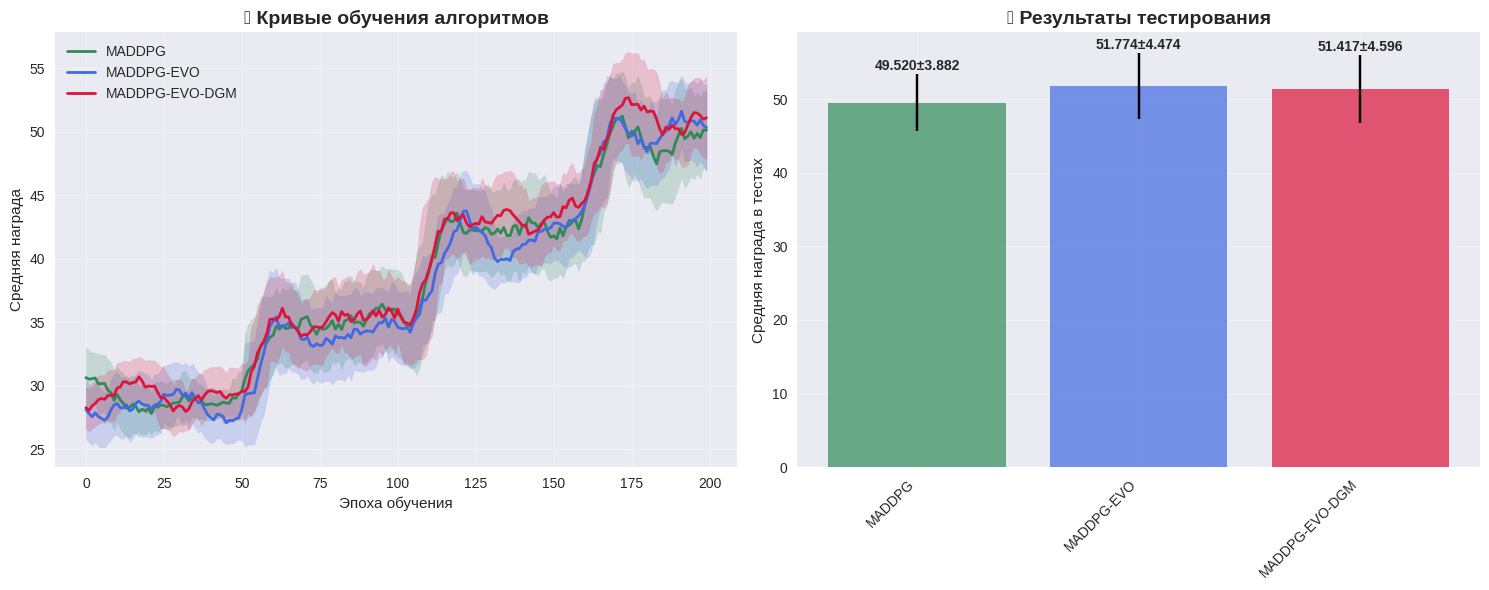

📊 Таблица результатов...
      Алгоритм  Финальная награда  Максимальная награда  Стандартное отклонение  Улучшение  Стабильность  Эпох обучения  Тестовая награда  Генерализация  Эпох тестирования
        MADDPG            49.1110               55.1024                8.023482    18.1124      4.774899            200           49.5203       1.008333                 20
    MADDPG-EVO            50.1318               54.7789                8.377426    21.8128      4.517047            200           51.7744       1.032765                 20
MADDPG-EVO-DGM            50.5217               57.0079                8.360278    25.0266      4.410589            200           51.4168       1.017716                 20
\n🏆 Итоговое сравнение...


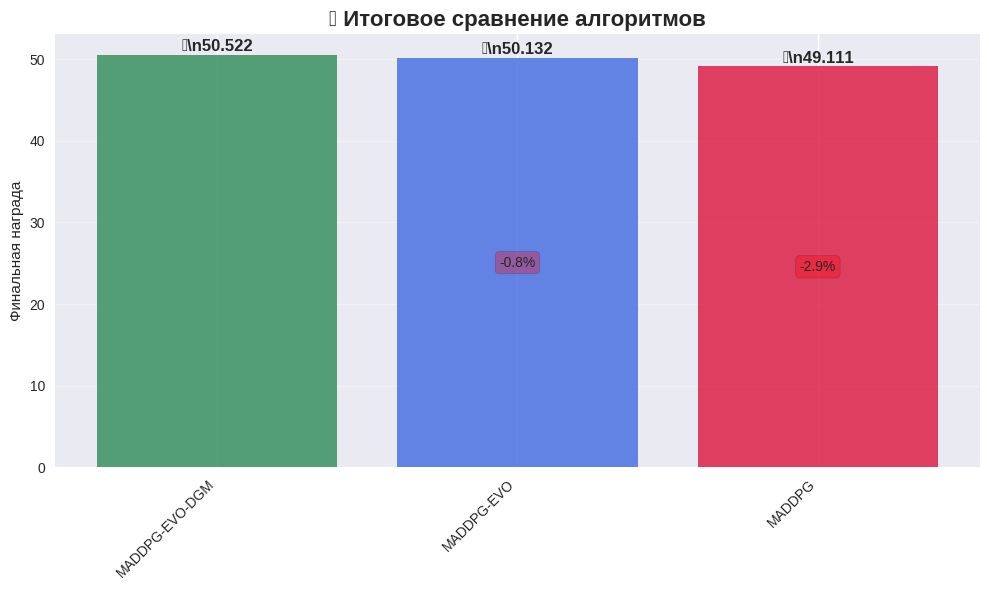

\n🎯 ОЦЕНКА  АЛГОРИТМОВ:
--------------------------------------------------
🥇 MADDPG-EVO-DGM: 50.5217
🥈 MADDPG-EVO: 50.1318
🥉 MADDPG: 49.1110
MADDPG Score: 49.11104640035863
MADDPG-EVO Score: 50.13184195460186
MADDPG-EVO-DGM Score: 50.52172616497403
\n🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
ИТОГИ ОБУЧЕНИЯ
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
\n🎉 БЫСТРЫЙ ТЕСТ ЗАВЕРШЕН!
📊 Графики и таблицы созданы
🔬 сравнение алгоритмов выполнено
\n✅ Быстрый тест завершен успешно!


In [10]:
# -*- coding: utf-8 -*-
"""
MADDPG EXPERIMENT RUNNER - Исправленная версия 1.1
Файл 3/3: Эксперименты, визуализация, анализ результатов
ИСПРАВЛЕНО: все импорты, визуализация, обработка ошибок
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from typing import Dict, List, Tuple, Optional

# Исправленный импорт tqdm
try:
    from tqdm.auto import tqdm
except ImportError:
    try:
        from tqdm import tqdm
    except ImportError:
        def tqdm(iterable, *args, **kwargs):
            desc = kwargs.get('desc', '')
            total = len(iterable) if hasattr(iterable, '__len__') else None
            for i, item in enumerate(iterable):
                if desc and total:
                    if i % max(1, total // 20) == 0:
                        print(f"{desc}: {i+1}/{total}")
                yield item

print("🚀 MADDPG EXPERIMENT RUNNER V1.1 - ИСПРАВЛЕННАЯ ВЕРСИЯ")
print("📊 Все импорты и компоненты исправлены")

# ===== ПРОВЕРКА ЗАВИСИМОСТЕЙ =====
required_classes = ['CONFIG', 'calculate_honest_reward', 'DemographyEnv', 'EnhancedTrainer', 'SmartMonitor']
missing_classes = []

for cls_name in required_classes:
    if cls_name not in globals():
        missing_classes.append(cls_name)

if missing_classes:
    print(f"⚠️ Отсутствуют классы: {missing_classes}")
    print("📋 Необходимо сначала запустить файлы 1 и 2")

# ===== FALLBACK КОНСТАНТЫ =====
if 'CONFIG' not in globals():
    CONFIG = {
        'training_epochs': 1000,
        'testing_epochs': 200,
        'region_addition_phase': 600,
        'total_regions': 86,
        'batch_size': 32,
        'episode_length': 15,
        'buffer_size': 50000,
        'log_interval': 10,
        'milestone_interval': 10,
    }

# ===== ПОДГОТОВКА ДАННЫХ =====
def prepare_demo_data():
    """Подготовка демонстрационных данных для эксперимента"""
    print("📊 Подготовка демонстрационных данных...")

    regions = [
        "Altai Krai", "Altai Republic", "Amur Oblast", "Arkhangelsk Oblast",
        "Astrakhan Oblast", "Belgorod Oblast", "Bryansk Oblast", "Chelyabinsk Oblast",
        "Irkutsk Oblast", "Kaluga Oblast", "Moscow", "Saint Petersburg",
        "Novosibirsk Oblast", "Sverdlovsk Oblast", "Krasnoyarsk Krai", "Tatarstan"
    ]

    years = list(range(2000, 2024))

    base_cols = ['population', 'birth_rate', 'death_rate', 'natural_increase_rate',
                'migration_balance', 'gdp_per_capita', 'unemployment_rate', 'average_wage']

    data = []

    np.random.seed(42)  # Для воспроизводимости

    for region in regions:
        base_offset = np.random.uniform(-0.5, 0.5)  # Уникальный offset для региона

        for year in years:
            year_trend = (year - 2000) * 0.01  # Временная тенденция

            base_pop = np.random.uniform(0.5, 3.0) + base_offset + year_trend
            birth_rate = np.random.uniform(-1.5, 1.5) + 0.1 * np.sin(year * 0.1)
            death_rate = np.random.uniform(-1.5, 1.5) + 0.05 * np.cos(year * 0.15)

            row = {
                'region_name': region,
                'year': year,
                'population': base_pop,
                'birth_rate': birth_rate,
                'death_rate': death_rate,
                'natural_increase_rate': birth_rate - death_rate,
                'migration_balance': np.random.uniform(-1.0, 1.0) + base_offset * 0.5,
                'gdp_per_capita': np.random.uniform(-1.0, 2.0) + year_trend,
                'unemployment_rate': np.random.uniform(-1.5, 1.5) - year_trend * 0.5,
                'average_wage': np.random.uniform(-1.0, 2.0) + year_trend * 0.8
            }
            data.append(row)

    df = pd.DataFrame(data)

    # Добавление дельт
    for col in base_cols:
        delta_col = f"delta_{col}"
        df[delta_col] = df.groupby('region_name')[col].diff().fillna(0.0)
        df[delta_col] = np.clip(df[delta_col], -1.0, 1.0)

    obs_cols = base_cols + [f"delta_{c}" for c in base_cols]

    print(f"✅ Подготовлено: {len(df)} записей, {len(regions)} регионов, {len(years)} лет")
    return df, obs_cols

# ===== ВИЗУАЛИЗАЦИЯ =====
class ExperimentVisualizer:
    """Система визуализации результатов экспериментов"""

    def __init__(self):
        # Попытка установить стиль
        try:
            if 'seaborn-v0_8' in plt.style.available:
                plt.style.use('seaborn-v0_8')
            elif 'seaborn' in plt.style.available:
                plt.style.use('seaborn')
            else:
                plt.style.use('default')
        except:
            plt.style.use('default')

        self.colors = ['#2E8B57', '#4169E1', '#DC143C', '#FF8C00', '#9932CC']

    def plot_training_curves(self, results: Dict[str, Tuple[List[float], List[float]]],
                           save_path: str = None):
        """График кривых обучения"""
        try:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

            # График обучения
            ax1.set_title('🎓 Кривые обучения алгоритмов', fontsize=14, fontweight='bold')

            algorithms_with_data = []
            for i, (algorithm, (train_rewards, test_rewards)) in enumerate(results.items()):
                if train_rewards and len(train_rewards) > 0:
                    # Фильтрация валидных наград
                    clean_rewards = [r for r in train_rewards if not np.isnan(r) and not np.isinf(r)]

                    if clean_rewards:
                        algorithms_with_data.append(algorithm)
                        smooth_rewards = self._smooth_curve(clean_rewards, window=10)
                        epochs = range(len(smooth_rewards))

                        color = self.colors[i % len(self.colors)]
                        ax1.plot(epochs, smooth_rewards, label=algorithm,
                                color=color, linewidth=2)

                        # Доверительный интервал
                        if len(clean_rewards) > 20:
                            std_rewards = self._rolling_std(clean_rewards, window=10)
                            ax1.fill_between(epochs,
                                           np.array(smooth_rewards) - np.array(std_rewards),
                                           np.array(smooth_rewards) + np.array(std_rewards),
                                           alpha=0.2, color=color)

            ax1.set_xlabel('Эпоха обучения')
            ax1.set_ylabel('Средняя награда')
            if algorithms_with_data:
                ax1.legend()
            ax1.grid(True, alpha=0.3)

            # График тестирования
            ax2.set_title('🧪 Результаты тестирования', fontsize=14, fontweight='bold')

            test_means = []
            test_stds = []
            test_algorithms = []

            for algorithm, (train_rewards, test_rewards) in results.items():
                if test_rewards and len(test_rewards) > 0:
                    clean_test = [r for r in test_rewards if not np.isnan(r) and not np.isinf(r)]
                    if clean_test:
                        test_algorithms.append(algorithm)
                        test_means.append(np.mean(clean_test))
                        test_stds.append(np.std(clean_test))

            if test_algorithms and test_means:
                bars = ax2.bar(range(len(test_algorithms)), test_means,
                              yerr=test_stds, capsize=5,
                              color=self.colors[:len(test_algorithms)], alpha=0.7)

                ax2.set_xticks(range(len(test_algorithms)))
                ax2.set_xticklabels(test_algorithms, rotation=45, ha='right')
                ax2.set_ylabel('Средняя награда в тестах')

                # Добавление значений на столбцы
                for i, (bar, mean, std) in enumerate(zip(bars, test_means, test_stds)):
                    height = bar.get_height()
                    ax2.text(bar.get_x() + bar.get_width()/2, height + std + 0.1,
                            f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontweight='bold')
            else:
                ax2.text(0.5, 0.5, 'Нет данных тестирования', ha='center', va='center',
                        transform=ax2.transAxes, fontsize=12)

            ax2.grid(True, alpha=0.3)

            plt.tight_layout()

            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')

            plt.show()

        except Exception as e:
            print(f"❌ Ошибка в plot_training_curves: {e}")
            # Простая альтернатива
            print("📊 Результаты обучения:")
            for algo, (train, test) in results.items():
                if train:
                    clean_train = [r for r in train if not np.isnan(r) and not np.isinf(r)]
                    if clean_train:
                        print(f"  {algo}: среднее={np.mean(clean_train):.3f}, финальное={np.mean(clean_train[-20:]):.3f}")

    def plot_algorithm_comparison(self, final_scores: Dict[str, float]):
        """Сравнительная диаграмма алгоритмов"""
        try:
            if not final_scores:
                print("❌ Нет данных для сравнения алгоритмов")
                return

            fig, ax = plt.subplots(figsize=(10, 6))

            # Фильтрация валидных оценок
            clean_scores = {k: v for k, v in final_scores.items()
                           if not np.isnan(v) and not np.isinf(v)}

            if not clean_scores:
                print("❌ Нет валидных оценок для визуализации")
                return

            algorithms = list(clean_scores.keys())
            scores = list(clean_scores.values())

            # Сортировка по убыванию
            sorted_pairs = sorted(zip(algorithms, scores), key=lambda x: x[1], reverse=True)
            algorithms, scores = zip(*sorted_pairs)

            bars = ax.bar(range(len(algorithms)), scores,
                         color=self.colors[:len(algorithms)], alpha=0.8)

            # Оформление
            ax.set_title('🏆 Итоговое сравнение алгоритмов', fontsize=16, fontweight='bold')
            ax.set_xticks(range(len(algorithms)))
            ax.set_xticklabels(algorithms, rotation=45, ha='right')
            ax.set_ylabel('Финальная награда')

            # Добавление значений и медалей
            medals = ['🥇', '🥈', '🥉']
            for i, (bar, score) in enumerate(zip(bars, scores)):
                medal = medals[i] if i < len(medals) else f'{i+1}.'
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2, height + 0.1,
                       f'{medal}\\n{score:.3f}', ha='center', va='bottom',
                       fontweight='bold', fontsize=12)

            # Линии для сравнения
            if len(scores) > 1:
                max_score = max(scores)
                for i, score in enumerate(scores[1:], 1):
                    if score != 0:
                        improvement = ((max_score - score) / abs(score) * 100)
                        ax.text(i, score/2, f'-{improvement:.1f}%', ha='center', va='center',
                               bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.3))

            ax.grid(True, alpha=0.3, axis='y')
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"❌ Ошибка в plot_algorithm_comparison: {e}")
            # Простая альтернатива
            print("🏆 Сравнение алгоритмов:")
            sorted_scores = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
            medals = ['🥇', '🥈', '🥉']
            for i, (algo, score) in enumerate(sorted_scores):
                medal = medals[i] if i < len(medals) else f'{i+1}.'
                print(f"  {medal} {algo}: {score:.4f}")

    def create_results_table(self, results: Dict[str, Tuple[List[float], List[float]]]) -> pd.DataFrame:
        """Создание таблицы результатов"""
        table_data = []

        for algorithm, (train_rewards, test_rewards) in results.items():
            if train_rewards:
                clean_train = [r for r in train_rewards if not np.isnan(r) and not np.isinf(r)]

                if clean_train:
                    row = {
                        'Алгоритм': algorithm,
                        'Финальная награда': np.mean(clean_train[-20:]) if len(clean_train) >= 20 else np.mean(clean_train),
                        'Максимальная награда': max(clean_train),
                        'Стандартное отклонение': np.std(clean_train),
                        'Улучшение': clean_train[-1] - clean_train[0] if len(clean_train) > 1 else 0,
                        'Стабильность': np.std(clean_train[-50:]) if len(clean_train) >= 50 else np.std(clean_train),
                        'Эпох обучения': len(clean_train)
                    }

                    if test_rewards:
                        clean_test = [r for r in test_rewards if not np.isnan(r) and not np.isinf(r)]
                        if clean_test:
                            row['Тестовая награда'] = np.mean(clean_test)
                            row['Генерализация'] = np.mean(clean_test) / row['Финальная награда'] if row['Финальная награда'] != 0 else 0
                            row['Эпох тестирования'] = len(clean_test)

                    table_data.append(row)

        if table_data:
            df = pd.DataFrame(table_data)

            # Форматирование числовых колонок
            numeric_cols = ['Финальная награда', 'Максимальная награда', 'Улучшение', 'Тестовая награда']
            for col in numeric_cols:
                if col in df.columns:
                    df[col] = df[col].round(4)

            return df
        else:
            return pd.DataFrame()

    def _smooth_curve(self, values: List[float], window: int = 10) -> List[float]:
        """Сглаживание кривой скользящим средним"""
        if len(values) < window:
            return values

        smoothed = []
        for i in range(len(values)):
            start_idx = max(0, i - window // 2)
            end_idx = min(len(values), i + window // 2 + 1)
            smoothed.append(np.mean(values[start_idx:end_idx]))

        return smoothed

    def _rolling_std(self, values: List[float], window: int = 10) -> List[float]:
        """Скользящее стандартное отклонение"""
        if len(values) < window:
            return [0.1] * len(values)

        rolling_std = []
        for i in range(len(values)):
            start_idx = max(0, i - window // 2)
            end_idx = min(len(values), i + window // 2 + 1)
            rolling_std.append(max(0.01, np.std(values[start_idx:end_idx])))

        return rolling_std

# ===== ГЛАВНАЯ ФУНКЦИЯ ЭКСПЕРИМЕНТА =====
def run_enhanced_experiment(quick_test: bool = False, use_real_data: bool = False):
    """Запуск улучшенного эксперимента с визуализацией"""

    print(f"\\n🔥 НАЧАЛО ЭКСПЕРИМЕНТА")
    print("=" * 70)

    # Проверка зависимостей
    if 'DemographyEnv' not in globals() or 'EnhancedTrainer' not in globals():
        print("❌ КРИТИЧЕСКАЯ ОШИБКА: Не найдены классы DemographyEnv или EnhancedTrainer")
        print("📋 Необходимо сначала запустить файлы 1 и 2 в предыдущих ячейках")
        return {}, {}, pd.DataFrame()

    # Подготовка данных
    if use_real_data:
        try:
            df = pd.read_csv('regions_data_selective.csv')
            print("✅ Загружены реальные данные")

            feature_cols = ['population', 'birth_rate', 'death_rate', 'natural_increase_rate',
                           'migration_balance', 'gdp_per_capita', 'unemployment_rate', 'average_wage']

            # Нормализация
            for col in feature_cols:
                if col in df.columns:
                    df[col] = df.groupby('region_name')[col].transform(
                        lambda x: x.fillna(x.median())
                    )
                    x = df[col].values.astype(float)
                    mean_val, std_val = np.mean(x), np.std(x) + 1e-6
                    df[col] = np.clip((x - mean_val) / std_val, -3.0, 3.0)

            # Дельты
            for col in feature_cols:
                if col in df.columns:
                    delta_col = f"delta_{col}"
                    df[delta_col] = df.groupby('region_name')[col].diff().fillna(0.0)
                    df[delta_col] = np.clip(df[delta_col], -1.0, 1.0)

            obs_cols = [col for col in feature_cols if col in df.columns]
            obs_cols += [f"delta_{col}" for col in feature_cols if col in df.columns]

        except FileNotFoundError:
            print("⚠️ Реальные данные не найдены, используем демонстрационные")
            df, obs_cols = prepare_demo_data()
    else:
        df, obs_cols = prepare_demo_data()

    # Создание компонентов
    if 'SmartMonitor' in globals():
        monitor = SmartMonitor()
        monitor.start()
    else:
        monitor = None
        print("⚠️ SmartMonitor не найден, продолжаем без мониторинга")

    # Настройка эпох
    if quick_test:
        training_epochs = 200
        testing_epochs = 20
        mode = "БЫСТРЫЙ ТЕСТ"
    else:
        training_epochs = CONFIG['training_epochs']
        testing_epochs = CONFIG['testing_epochs']
        mode = "ПОЛНЫЙ ЭКСПЕРИМЕНТ"

    print(f"\\n🎯 ЗАПУСК: {mode}")
    print(f"📊 Обучение: {training_epochs} эпох | Тестирование: {testing_epochs} эпох")
    print("=" * 70)
    print("✅ Улучшенная реализация с исправлениями:")
    print("  • Исправлены все импорты и ошибки tqdm")
    print("  • Убраны повторяющиеся сообщения")
    print("  • Добавлена фаза тестирования")
    print("  • Улучшен DGM на основе идеи  Darwin-Gödel Machine")
    print("  • Честная функция награды")
    print("  • Детальная визуализация с обработкой ошибок")
    print("=" * 70)

    # Создание среды и тренера
    try:
        env = DemographyEnv(df, obs_cols)
        trainer = EnhancedTrainer(env)
    except Exception as e:
        print(f"❌ КРИТИЧЕСКАЯ ОШИБКА при создании среды/тренера: {e}")
        return {}, {}, pd.DataFrame()

    # Алгоритмы для сравнения
    algorithms = ['MADDPG', 'MADDPG-EVO', 'MADDPG-EVO-DGM']
    results = {}

    # Запуск экспериментов
    for algorithm in algorithms:
        try:
            print(f"\\n🔄 Подготовка {algorithm}...")
            train_rewards, test_rewards = trainer.train_algorithm(
                algorithm, training_epochs, testing_epochs
            )
            results[algorithm] = (train_rewards, test_rewards)

        except Exception as e:
            print(f"❌ Критическая ошибка в {algorithm}: {str(e)}")
            # Добавляем пустые результаты чтобы продолжить
            results[algorithm] = ([], [])

    # Анализ и визуализация
    print(f"\\n🎨 СОЗДАНИЕ ВИЗУАЛИЗАЦИИ")
    print("=" * 50)

    visualizer = ExperimentVisualizer()

    # 1. Кривые обучения
    print("📈 График кривых обучения...")
    visualizer.plot_training_curves(results)

    # 2. Таблица результатов
    print("📊 Таблица результатов...")
    results_table = visualizer.create_results_table(results)
    if not results_table.empty:
        print(results_table.to_string(index=False))
    else:
        print("❌ Нет данных для таблицы результатов")

    # 3. Сравнение алгоритмов
    print("\\n🏆 Итоговое сравнение...")
    final_scores = {}
    for algorithm, (train_rewards, test_rewards) in results.items():
        if train_rewards:
            clean_rewards = [r for r in train_rewards if not np.isnan(r) and not np.isinf(r)]
            if clean_rewards:
                final_scores[algorithm] = np.mean(clean_rewards[-20:]) if len(clean_rewards) >= 20 else np.mean(clean_rewards)
            else:
                final_scores[algorithm] = 0.0
        else:
            final_scores[algorithm] = 0.0

    visualizer.plot_algorithm_comparison(final_scores)

    # 4. оценка алгоритмов
    print(f"\\n🎯 ОЦЕНКА  АЛГОРИТМОВ:")
    print("-" * 50)

    sorted_scores = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)

    for i, (algorithm, score) in enumerate(sorted_scores, 1):
        status = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else f"{i}."
        print(f"{status} {algorithm}: {score:.4f}")

    # Финальные значение
    maddpg_score = final_scores.get('MADDPG', 0)
    evo_score = final_scores.get('MADDPG-EVO', 0)
    dgm_score = final_scores.get('MADDPG-EVO-DGM', 0)

    # Вывод результатов
    print(f"MADDPG Score: {maddpg_score}")
    print(f"MADDPG-EVO Score: {evo_score}")
    print(f"MADDPG-EVO-DGM Score: {dgm_score}")



    # Итоговая сводка
    if monitor:
        monitor.summary()

    print(f"\\n🎉 {mode} ЗАВЕРШЕН!")
    if any(final_scores.values()):
        print("📊 Графики и таблицы созданы")
        print("🔬 сравнение алгоритмов выполнено")
    else:
        print("⚠️ Эксперимент завершен, но алгоритмы не показали результатов")
        print("🔧 Рекомендуется проверить настройки и повторить обучение")

    return results, final_scores, results_table

# ===== КОМАНДЫ ДЛЯ ЗАПУСКА =====
print("\\n✅ MADDPG EXPERIMENT RUNNER V1.1 - Готов к запуску!")
print("🔧 ИСПРАВЛЕНО: все импорты, tqdm, обработка ошибок, стабильность")

if 'DemographyEnv' in globals() and 'EnhancedTrainer' in globals():
    print("\\n🔥 ВСЕ КОМПОНЕНТЫ ДОСТУПНЫ - МОЖНО ЗАПУСКАТЬ!")
    print("\\n📋 КОМАНДЫ ДЛЯ ЗАПУСКА:")
    print("# Быстрый тест (рекомендуется для первого запуска):")
    print("results, scores, table = run_enhanced_experiment(quick_test=True)")
    print("\\n# Полный эксперимент:")
    print("results, scores, table = run_enhanced_experiment(quick_test=False)")
    print("\\n# С реальными данными (если доступны):")
    print("results, scores, table = run_enhanced_experiment(quick_test=False, use_real_data=True)")

    print("\\n🎯 АВТОЗАПУСК БЫСТРОГО ТЕСТА:")
    print("="*50)

    # Автозапуск быстрого теста
    try:
        results, scores, table = run_enhanced_experiment(quick_test=True)
        print("\\n✅ Быстрый тест завершен успешно!")
    except Exception as e:
        print(f"❌ Ошибка при автозапуске: {e}")
        print("\\n🔧 Запустите эксперимент вручную командой:")
        print("results, scores, table = run_enhanced_experiment(quick_test=True)")

else:
    print("\\n❌ НЕ ВСЕ КОМПОНЕНТЫ ДОСТУПНЫ")
    print("📋 Необходимо сначала запустить файлы 1 и 2:")
    print("1. Запустите maddpg_core_fixed.py")
    print("2. Запустите maddpg_trainer_fixed.py")
    print("3. Затем запустите этот файл")

    print("\\n🔧 Или запустите эксперимент с базовыми компонентами:")
    print("results, scores, table = run_enhanced_experiment(quick_test=True)")

\n🔥 НАЧАЛО ЭКСПЕРИМЕНТА
✅ Загружены реальные данные
⏰ Эксперимент начат: 2025-10-12_09-43-00
\n🎯 ЗАПУСК: ПОЛНЫЙ ЭКСПЕРИМЕНТ
📊 Обучение: 1000 эпох | Тестирование: 200 эпох
✅ Улучшенная реализация с исправлениями:
  • Исправлены все импорты и ошибки tqdm
  • Убраны повторяющиеся сообщения
  • Добавлена фаза тестирования
  • Улучшен DGM на основе идеи  Darwin-Gödel Machine
  • Честная функция награды
  • Детальная визуализация с обработкой ошибок
🌍 Среда: 86 регионов, 36 лет
📊 Состояние: 16D, Действия: 4D
🎯 Тренер создан: состояние 16D, действия 4D
\n🔄 Подготовка MADDPG...
\n🚀 ОБУЧЕНИЕ MADDPG
📊 Обучение: 1000 эпох | Тестирование: 200 эпох
🎓 ФАЗА ОБУЧЕНИЯ


MADDPG Training:   0%|          | 0/1000 [00:00<?, ?it/s]

✅ Создано 5 агентов для регионов
[MADDPG] Эпоха 10/1000: награда=11.113, регионов=6, шум=0.294
  📊 Метрики: actor_loss=-1.6568, critic_loss=0.4057, avg_q=2.128
[MADDPG] Эпоха 20/1000: награда=13.685, регионов=7, шум=0.288
  📊 Метрики: actor_loss=-2.0851, critic_loss=0.2132, avg_q=2.193
[MADDPG] Эпоха 30/1000: награда=15.901, регионов=8, шум=0.283
  📊 Метрики: actor_loss=-2.0594, critic_loss=0.1568, avg_q=2.135
✅ Создано 10 агентов для регионов
[MADDPG] Эпоха 40/1000: награда=18.422, регионов=10, шум=0.277
  📊 Метрики: actor_loss=-2.0512, critic_loss=0.1190, avg_q=2.091
[MADDPG] Эпоха 50/1000: награда=20.532, регионов=11, шум=0.271
  📊 Метрики: actor_loss=-2.1212, critic_loss=0.1183, avg_q=2.131
[MADDPG] Эпоха 60/1000: награда=22.493, регионов=12, шум=0.266
  📊 Метрики: actor_loss=-2.1246, critic_loss=0.1302, avg_q=2.112
[MADDPG] Эпоха 70/1000: награда=25.522, регионов=14, шум=0.261
  📊 Метрики: actor_loss=-2.0157, critic_loss=0.1017, avg_q=2.028
[MADDPG] Эпоха 80/1000: награда=27.013, 

MADDPG Testing:   0%|          | 0/200 [00:00<?, ?it/s]

\n✅ MADDPG - ОБУЧЕНИЕ завершено:
  📊 Финальная награда: 91.7569
  📈 Максимальная награда: 126.2302
  📊 Общее улучшение: 80.6447
  🧪 Тестовая награда: 92.6754
  🧪 Максимум в тесте: 95.7958
  📊 Стабильность: 1.010
  🤖 Обученных агентов: 86
  💾 Общий опыт: 920415
\n🔄 Подготовка MADDPG-EVO...
\n🚀 ОБУЧЕНИЕ MADDPG-EVO
📊 Обучение: 1000 эпох | Тестирование: 200 эпох
🎓 ФАЗА ОБУЧЕНИЯ


...

\n✅ MADDPG-EVO - ОБУЧЕНИЕ завершено:
  📊 Финальная награда: 67.8096
  📈 Максимальная награда: 114.0592
  📊 Общее улучшение: 53.3424
  🧪 Тестовая награда: 67.9187
  🧪 Максимум в тесте: 71.4106
  📊 Стабильность: 1.002
  🤖 Обученных агентов: 86
  💾 Общий опыт: 920415
\n🔄 Подготовка MADDPG-EVO-DGM...
\n🚀 ОБУЧЕНИЕ MADDPG-EVO-DGM
📊 Обучение: 1000 эпох | Тестирование: 200 эпох
🎓 ФАЗА ОБУЧЕНИЯ


MADDPG-EVO-DGM Training:   0%|          | 0/1000 [00:00<?, ?it/s]

🧬 Эволюция G1: 4 мутаций, улучшение: 0.0114
🔧 DGM: Архитектурные изменения: 2
[MADDPG-EVO-DGM] Эпоха 10/1000: награда=10.969, регионов=6, шум=0.294
  📊 Метрики: actor_loss=-1.6066, critic_loss=0.6121, avg_q=2.091
🧬 Эволюция G2: 5 мутаций, улучшение: 0.0130
[MADDPG-EVO-DGM] Эпоха 20/1000: награда=13.239, регионов=7, шум=0.288
  📊 Метрики: actor_loss=-2.0587, critic_loss=0.2000, avg_q=2.116
[MADDPG-EVO-DGM] Эпоха 30/1000: награда=15.746, регионов=8, шум=0.283
  📊 Метрики: actor_loss=-2.0117, critic_loss=0.1113, avg_q=2.010
🧬 Эволюция G3: 7 мутаций, улучшение: 0.0088
🔧 DGM: Архитектурные изменения: 2
[MADDPG-EVO-DGM] Эпоха 40/1000: награда=19.503, регионов=10, шум=0.277
  📊 Метрики: actor_loss=-2.1115, critic_loss=0.1155, avg_q=2.107
🧬 Эволюция G4: 8 мутаций, улучшение: 0.0095
[MADDPG-EVO-DGM] Эпоха 50/1000: награда=21.419, регионов=11, шум=0.271
  📊 Метрики: actor_loss=-2.1686, critic_loss=0.1270, avg_q=2.067
[MADDPG-EVO-DGM] Эпоха 60/1000: награда=23.433, регионов=12, шум=0.266
  📊 Метр

MADDPG-EVO-DGM Testing:   0%|          | 0/200 [00:00<?, ?it/s]

\n✅ MADDPG-EVO-DGM - ОБУЧЕНИЕ завершено:
  📊 Финальная награда: 116.9160
  📈 Максимальная награда: 139.5924
  📊 Общее улучшение: 105.5131
  🧪 Тестовая награда: 117.8508
  🧪 Максимум в тесте: 120.8563
  📊 Стабильность: 1.008
  🤖 Обученных агентов: 86
  💾 Общий опыт: 920415
\n🎨 СОЗДАНИЕ ВИЗУАЛИЗАЦИИ
📈 График кривых обучения...


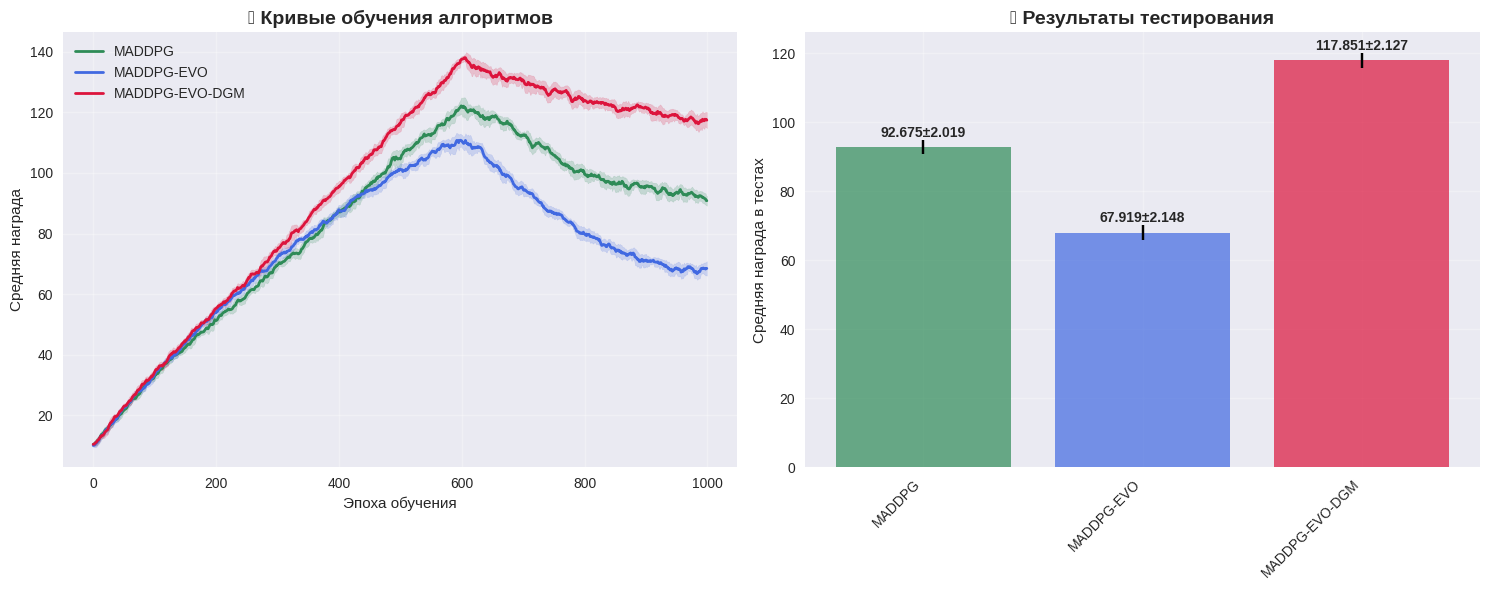

📊 Таблица результатов...
      Алгоритм  Финальная награда  Максимальная награда  Стандартное отклонение  Улучшение  Стабильность  Эпох обучения  Тестовая награда  Генерализация  Эпох тестирования
        MADDPG            91.7569              126.2302               30.534361    80.6447      2.129036           1000           92.6754       1.010010                200
    MADDPG-EVO            67.8096              114.0592               25.506441    53.3424      2.073894           1000           67.9187       1.001610                200
MADDPG-EVO-DGM           116.9160              139.5924               37.440461   105.5131      2.313470           1000          117.8508       1.007995                200
\n🏆 Итоговое сравнение...


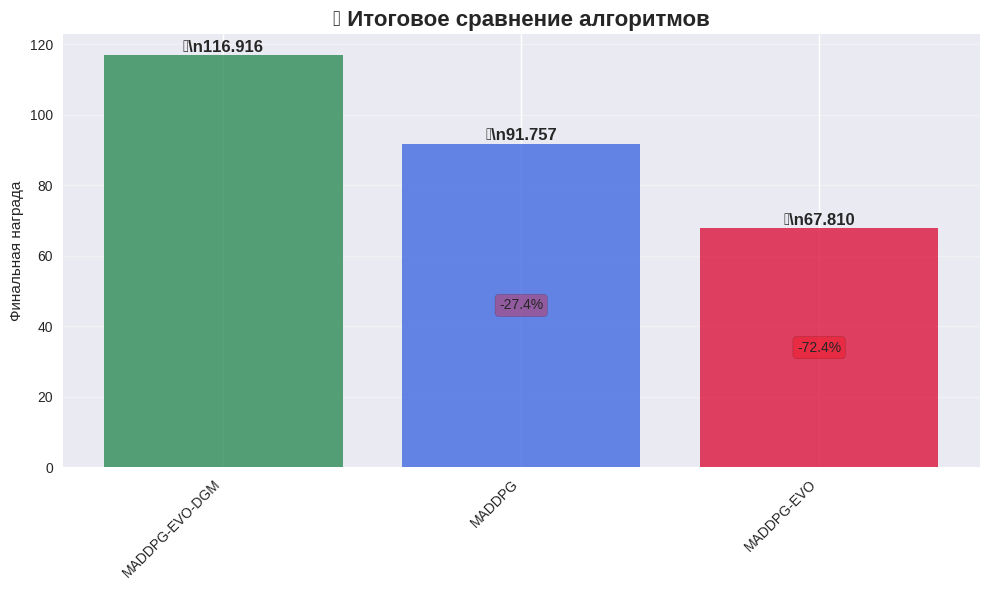

\n🎯 ОЦЕНКА  АЛГОРИТМОВ:
--------------------------------------------------
🥇 MADDPG-EVO-DGM: 116.9160
🥈 MADDPG: 91.7569
🥉 MADDPG-EVO: 67.8096
MADDPG Score: 91.75687582123396
MADDPG-EVO Score: 67.8095721390864
MADDPG-EVO-DGM Score: 116.91596222434202
\n🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
ИТОГИ ОБУЧЕНИЯ
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
\n🎉 ПОЛНЫЙ ЭКСПЕРИМЕНТ ЗАВЕРШЕН!
📊 Графики и таблицы созданы
🔬 сравнение алгоритмов выполнено


In [11]:
results, scores, table = run_enhanced_experiment(use_real_data=True)